# Install Library

In [ ]:
!pip -q install tensorflow

# Import Library

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Attention,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Mount Gdrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/ABSA_Training_New/train.csv"
VALID_PATH = "/content/drive/MyDrive/ABSA_Training_New/validation.csv"
TEST_PATH = "/content/drive/MyDrive/ABSA_Training_New/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)

(6368, 6)
(796, 6)
(797, 6)


In [ ]:
train_df = train_df.dropna(subset=["sentiment"])
valid_df = valid_df.dropna(subset=["sentiment"])
test_df = test_df.dropna(subset=["sentiment"])

In [ ]:
train_df["input_text"] = (
    train_df["aspect"] + " : " + train_df["text"]
)

valid_df["input_text"] = (
    valid_df["aspect"] + " : " + valid_df["text"]
)

test_df["input_text"] = (
    test_df["aspect"] + " : " + test_df["text"]
)

In [ ]:
MAX_WORDS = 30000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    train_df["input_text"]
)

In [ ]:
X_train = tokenizer.texts_to_sequences(
    train_df["input_text"]
)

X_valid = tokenizer.texts_to_sequences(
    valid_df["input_text"]
)

X_test = tokenizer.texts_to_sequences(
    test_df["input_text"]
)

In [ ]:
MAX_LEN = 100

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_valid = pad_sequences(
    X_valid,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
y_train = train_df["sentiment_label"].values
y_valid = valid_df["sentiment_label"].values
y_test = test_df["sentiment_label"].values

# BiLSTM + Attention Model

In [ ]:
VOCAB_SIZE = min(
    MAX_WORDS,
    len(tokenizer.word_index)+1
)

inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=128
)(inputs)

bilstm = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(embedding)

attention = Attention()(
    [bilstm, bilstm]
)

pooling = GlobalAveragePooling1D()(
    attention
)

dropout = Dropout(0.5)(
    pooling
)

dense = Dense(
    64,
    activation="relu"
)(dropout)

dropout2 = Dropout(0.3)(
    dense
)

outputs = Dense(
    3,
    activation="softmax"
)(dropout2)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  1,127,808 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 256)  │    263,168 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 256)  │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,407,619 (5.37 MB)

 Trainable params: 1,407,619 (5.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5636395822269428), np.int64(1): np.float64(8.918767507002801), np.int64(2): np.float64(0.8979131415679639)}


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 90s 427ms/step - accuracy: 0.5693 - loss: 0.8362 - val_accuracy: 0.7010 - val_loss: 0.7718
Epoch 2/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 88s 441ms/step - accuracy: 0.8274 - loss: 0.5339 - val_accuracy: 0.7902 - val_loss: 0.6666
Epoch 3/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 79s 398ms/step - accuracy: 0.8777 - loss: 0.3917 - val_accuracy: 0.8907 - val_loss: 0.3692
Epoch 4/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 80s 402ms/step - accuracy: 0.9194 - loss: 0.2808 - val_accuracy: 0.9020 - val_loss: 0.3577
Epoch 5/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 79s 399ms/step - accuracy: 0.9336 - loss: 0.2267 - val_accuracy: 0.8995 - val_loss: 0.3599
Epoch 6/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 82s 398ms/step - accuracy: 0.9405 - loss: 0.1890 - val_accuracy: 0.9008 - val_loss: 0.3667
Epoch 7/15
199/199 ━━━━━━━━━━━━━━━━━━━━ 79s 398ms/step - accuracy: 0.9480 - loss: 0.1564 - val_accuracy: 0.8907 - val_loss: 0.3754


In [ ]:
# PREDICTION

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step


In [ ]:
# EVALUATION

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.8883312421580929
Precision: 0.8547497938295292
Recall : 0.8883312421580929
F1 Score : 0.8711545097992066


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       471
           1       0.00      0.00      0.00        30
           2       0.88      0.89      0.88       296

    accuracy                           0.89       797
   macro avg       0.59      0.61      0.60       797
weighted avg       0.85      0.89      0.87       797



In [ ]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[444,   0,  27],
       [ 20,   0,  10],
       [ 32,   0, 264]])

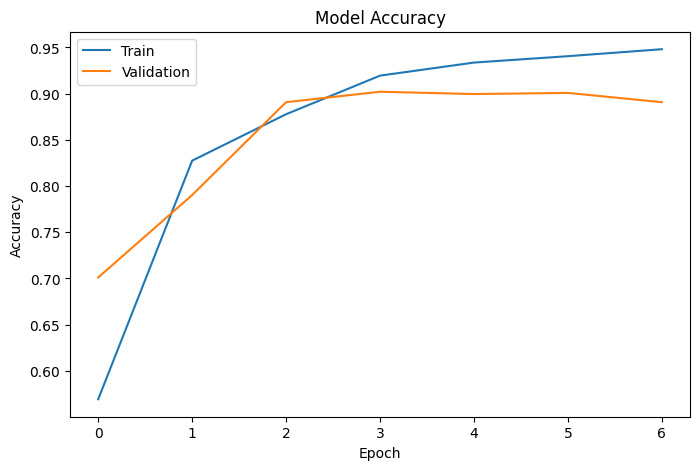

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

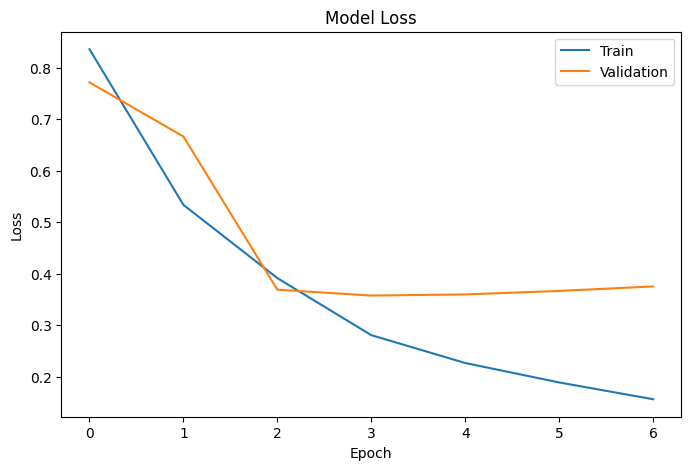

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

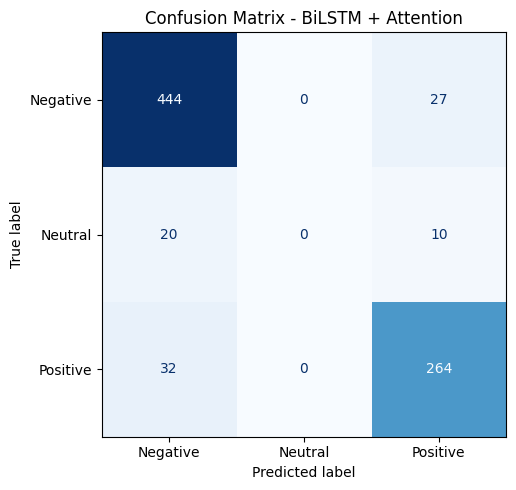

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]  # sesuaikan dengan mapping LabelEncoder
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - BiLSTM + Attention")
plt.tight_layout()
plt.show()